# Práctica Integradora - Implementación de un Data Warehouse en BigQuery

## Integrantes Grupo 3:
- Beatriz Eunice Beltrán López
- Brenda Nicole Henríquez Amaya
- Jonathan Vladimir Montes Rodríguez

---

## Objetivo General

Implementar un entorno básico de análisis de datos en Google BigQuery utilizando Python y Jupyter Notebook, aplicando conceptos de carga de datos, consultas analíticas, optimización de costos y construcción de un Data Mart para la generación de información estratégica.

---

## Caso de Negocio

La empresa Retail Data Group posee operaciones en Guatemala, El Salvador, Honduras y Costa Rica.

La organización desea centralizar la información de ventas para responder preguntas como:

* ¿Cuál es el producto más vendido?
* ¿Cuál es la sucursal con mayores ingresos?
* ¿Cuál es el país con mejor desempeño?
* ¿Cuáles son los clientes más importantes?
* ¿Cuál es la tendencia mensual de ventas?

Para ello se ha decidido implementar una solución analítica utilizando BigQuery.

---

## Arquitectura Implementada

Para resolver las necesidades analíticas de Retail Data Group, se diseñó e implementó una arquitectura de datos moderna basada en un pipeline ELT (Extract, Load, Transform) acoplado a la nube. Tomando como referencia el modelo empresarial recomendado en la industria para la gestión de datos, el equipo adaptó y simplificó los componentes clave para ajustarlos a los objetivos de este laboratorio analítico.

A continuación, se presenta el mapeo del flujo de datos desde su origen local hasta la capa de presentación final en la nube:

```text
Fuentes de Datos (Sintéticas con Faker)
                ↓
  Jupyter Notebook (Python / venv)
                ↓
    Data Warehouse (BigQuery)
                ↓
      SQL / Tablas Locales
                ↓
  Data Mart (retail_dw.clientes/productos/ventas)
                ↓
      Dashboard (Matplotlib / Python)
```

---

### Componentes de la Solución y Justificación Técnica:

1. **Capa de Generación de Datos (Fuentes de Datos ➔ Python + Faker):** Utilizando Python en un entorno virtual aislado (`venv`), se simulan las operaciones regionales de Centroamérica mediante la librería `Faker` y el módulo nativo `random`. Se generan tres archivos planos en formato `.csv` (`clientes.csv`, `productos.csv` y `ventas.csv`) que representan la actividad transaccional real del negocio (fuentes de datos), acumulando un total de 100,000 registros de ventas.

2. **Capa de Orquestación y Conexión (Airflow ➔ Jupyter Notebook):** La comunicación entre el entorno local y la infraestructura de nube se realiza mediante el SDK oficial de Google Cloud (`google-cloud-bigquery`), controlando el flujo secuencial desde Jupyter en lugar de un orquestador pesado como Airflow. La autenticación se gestiona a través de una Cuenta de Servicio (*Service Account*) con el rol de **BigQuery Admin**, validada localmente mediante una llave privada en formato JSON (`service_account.json`), la cual se mantiene protegida fuera del repositorio Git mediante reglas estrictas en el archivo `.gitignore`.

3. **Capa de Almacenamiento y Cómputo (Cloud Storage ➔ Ingesta Directa a Data Warehouse):** Los datos se centralizan en Google BigQuery dentro del conjunto de datos analítico (`retail_dw`). Para agilizar la carga en este laboratorio, se omitió el almacenamiento intermedio en un Data Lake (como Cloud Storage); los DataFrames de Pandas se inyectan directamente en el motor analítico ahorrando tiempos de transferencia.

4. **Capa de Modelado y Rendimiento (dbt ➔ SQL Nativo y Optimización):** En lugar de implementar una herramienta externa como *dbt* para transformar los datos, el diseño del modelo relacional (Data Mart) se ejecuta directamente en BigQuery mediante sentencias SQL nativas (patrón ELT). La estructura se compone de tres tablas principales (`clientes`, `productos` y `ventas`) optimizadas para consultas de agregación masiva mediante estrategias de **Particionamiento por fecha** (`fecha_venta`), **Clustering por región** (`sucursal`) y el despliegue de **Vistas Materializadas**.

5. **Capa de Consumo y Business Intelligence (Power BI/Tableau ➔ Matplotlib):** El análisis final de los datos y la respuesta a las preguntas estratégicas del negocio se ejecutan mediante consultas SQL avanzadas en BigQuery. En sustitución de un software de reportería tradicional, los resultados se conectan directamente con librerías de visualización en Python (`matplotlib` / `pandas`), permitiendo la creación de un tablero exploratorio integrado en el mismo entorno de trabajo.

# Parte 1 - Configuración del Entorno

Para garantizar el aislamiento de las dependencias y la portabilidad del pipeline entre los integrantes, se utilizó la herramienta nativa `venv` de Python en lugar de Anaconda.

---

## Crear y Activar Entorno Virtual

1. **Creación del entorno:** Se generó la carpeta aislada `.venv` en la raíz del proyecto:

```bash
   python -m venv .venv

```

2. **Permisos de PowerShell:** En Windows, se ejecutó el siguiente comando para permitir la activación de scripts en el perfil de usuario:

```powershell
Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser

```


3. **Activación:** Se inició el entorno virtual en la terminal:
```powershell
.venv\Scripts\Activate.ps1

```



---

## Instalación de Librerías

Se definieron las versiones exactas en el archivo de gobernanza `requirements.txt`:

```text
pandas==2.2.2
pyarrow==16.1.0
google-cloud-bigquery==3.24.0
db-dtypes==1.2.0
jupyter==1.0.0
faker==33.3.0

```

Para instalar de forma masiva las dependencias del proyecto, se ejecutó:

```bash
pip install -r requirements.txt

```

> **Nota de Buenas Prácticas:** El uso de `requirements.txt` con versiones fijas garantiza la **replicabilidad exacta del entorno**, asegurando que el pipeline funcione idéntico para todo el equipo. Además, protege el código contra actualizaciones de terceros (*breaking changes*) que puedan romper funciones y facilita un despliegue controlado desde GitHub.

---

## Iniciar Jupyter Notebook

Con el entorno aislado y configurado, se inicializó el servidor local para el desarrollo del pipeline ELT:

```bash
jupyter notebook

```

---

# Parte 2 - Configuración de Google Cloud

Para habilitar la infraestructura analítica en la nube, se configuraron los servicios esenciales de Google Cloud Platform (GCP) garantizando el acceso seguro y controlado desde el entorno local.

---

## Crear Proyecto

Se inicializó un espacio de trabajo aislado en la consola de administración de GCP para centralizar y aislar todos los recursos analíticos del laboratorio.

* **Nombre asignado al Proyecto:** `retail-analytics-lab`

**Evidencia de Proyecto Activo en Google Cloud**

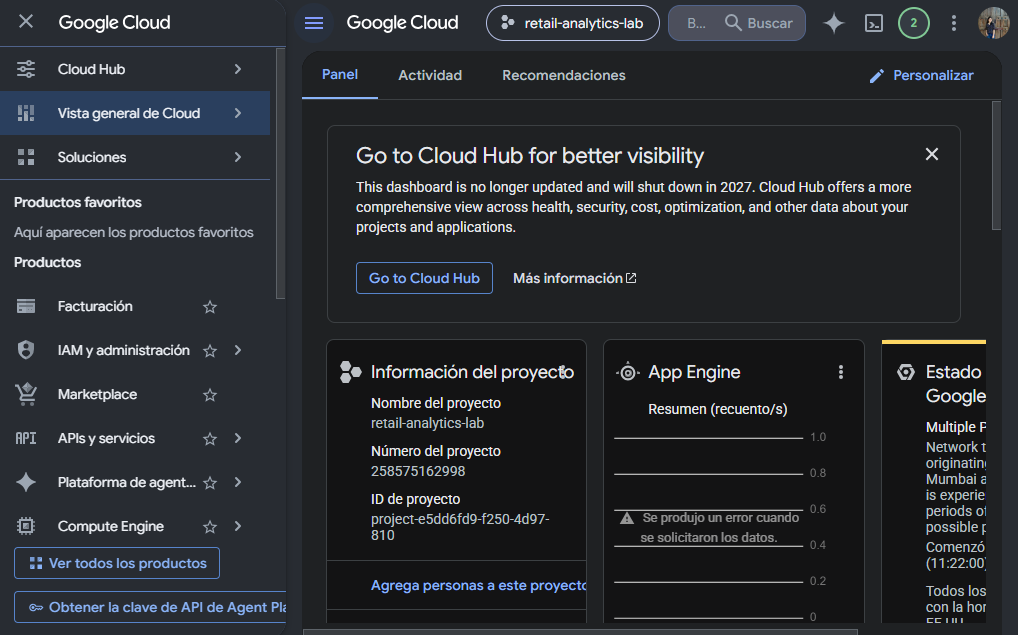

---

## Habilitar BigQuery API

Para permitir que Python interactúe programáticamente con el motor analítico desde nuestro entorno local, se activó la API de BigQuery en la consola de administración siguiendo esta ruta:

```text
Google Cloud Console
↓
APIs & Services
↓
Enable APIs and Services
↓
Buscar: BigQuery API ➔ Seleccionar ➔ Habilitar
```

**Evidencia de API Habilitada:**

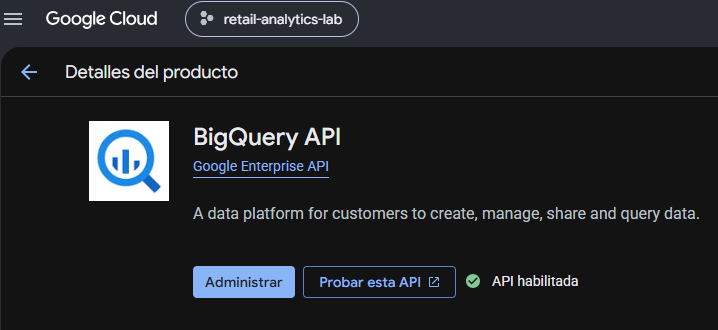

---

## Crear Service Account

Se creó una identidad de máquina dedicada a la automatización de procesos para permitir que los scripts locales ejecuten comandos en la nube de forma segura.

```text
IAM & Admin
↓
Service Accounts
↓
Create Service Account

```

* **Rol asignado:** `BigQuery Admin` (permiso total para la gestión y consulta del Data Warehouse).

**Evidencia de Cuenta de Servicio Autorizada:**

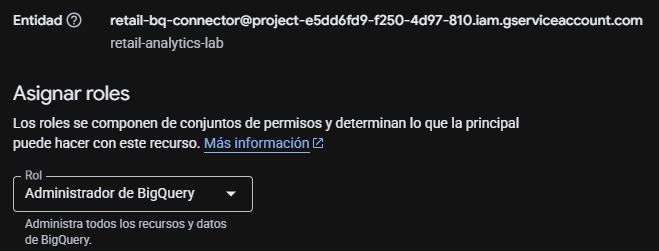

---

## Descargar Credenciales

Se generó y descargó la llave privada en formato JSON para permitir la autenticación remota.

```text
service_account.json

```

* **Ruta de almacenamiento local:** `/proyecto/credentials/`

> **Nota de Seguridad:** Se agregó la regla `credentials/` en el archivo `.gitignore` para evitar que la llave privada se suba al repositorio público de GitHub y proteger el acceso a la nube.

**Evidencia de Clave Privada Generada:**

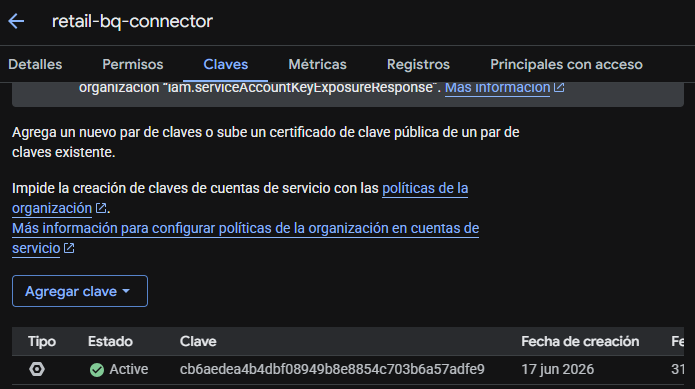

---

# Parte 4 y 5 - Creación de Dataset y Tablas (Modelo Star Schema) desde Python

Para inicializar la infraestructura de datos de forma automatizada, se utilizó la librería oficial `google-cloud-bigquery` en Jupyter. Esto permitió estructurar el almacén de datos directamente en la nube mediante un **Modelo en Estrella (Star Schema)** compuesto por tablas de dimensiones y una tabla de hechos central.

---

## 1. Inicialización del Dataset

Se creó programáticamente el espacio lógico (esquema) en la ubicación geográfica correspondiente:

```python
from google.cloud import bigquery

# Inicializar cliente con credenciales de gobernanza
client = bigquery.Client.from_service_account_json("credentials/service_account.json")

# Configurar y desplegar el Dataset
dataset_id = f"{client.project}.retail_dw"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

dataset = client.create_dataset(dataset, exists_ok=True)
print(f"Dataset {dataset.dataset_id} inicializado.")

```

---

## 2. Definición del Esquema Analítico (DDL)

Se encapsularon y ejecutaron las sentencias SQL correspondientes para construir el catálogo de dimensiones (`dim_clientes`, `dim_productos`) y la tabla transaccional de hechos (`fact_ventas`), aplicando restricciones analíticas de clave primaria.

```python
# Definición de consultas DDL
query_clientes = """
CREATE OR REPLACE TABLE retail_dw.dim_clientes (
    cliente_id STRING NOT NULL, nombre STRING, email STRING, telefono STRING, direccion STRING, fecha_registro DATE,
    PRIMARY KEY (cliente_id) NOT ENFORCED
);
"""

query_productos = """
CREATE OR REPLACE TABLE retail_dw.dim_productos (
    producto_id STRING NOT NULL, nombre_producto STRING, categoria STRING, precio_unitario FLOAT64,
    PRIMARY KEY (producto_id) NOT ENFORCED
);
"""

query_ventas = """
CREATE OR REPLACE TABLE retail_dw.fact_ventas (
    venta_id STRING NOT NULL, fecha_venta TIMESTAMP, cliente_id STRING, producto_id STRING, cantidad INT64, total_venta FLOAT64,
    PRIMARY KEY (venta_id) NOT ENFORCED
);
"""

# Ejecución de queries en el motor analítico
client.query(query_clientes).result()
client.query(query_productos).result()
client.query(query_ventas).result()
print("Estructura del Star Schema desplegada exitosamente.")

```

**Evidencia de Infraestructura y Esquema Desplegado en BigQuery:**

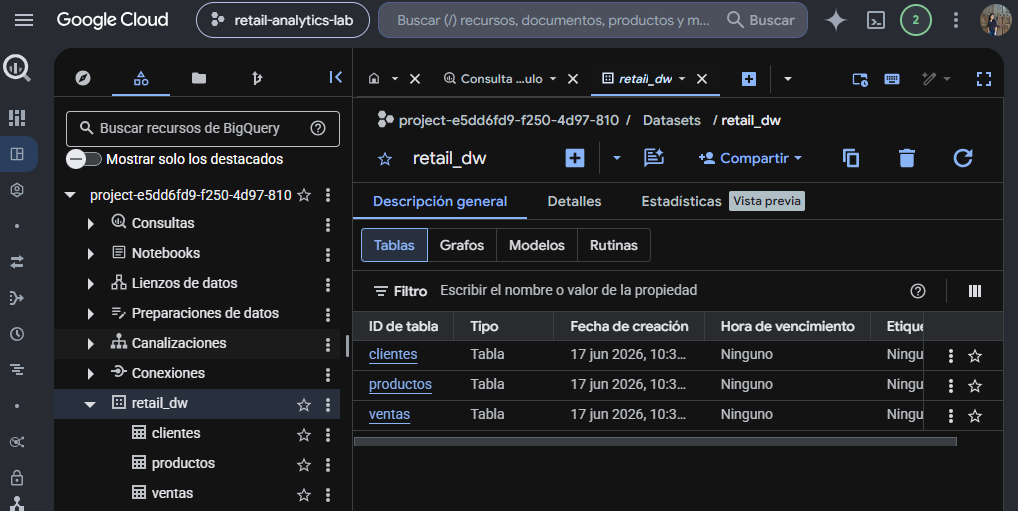

---

# Parte 6 - Generación de Datos con Python

Para alimentar nuestro esquema analítico, se desarrolló un script en Python utilizando la librería `Faker` y `Pandas`. Este proceso permitió la creación de un volumen masivo de datos transaccionales simulados, recreando el comportamiento y la estructura de un entorno retail real.

El código genera de forma automatizada las dimensiones principales (Clientes y Productos) y la tabla de hechos (Ventas). Además, asegura la coherencia lógica de los datos (como asignar sucursales válidas según el país del cliente) y exporta los resultados estructurados a la carpeta `datasets`.

```python
import pandas as pd
import random
import os
from faker import Faker
from datetime import datetime, timedelta

# Inicializamos Faker
fake = Faker('es_MX')

# Asegurar que el directorio de salida exista
output_dir = '../datasets'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Iniciando la generación de datos en la carpeta: {output_dir}/")

# 1. Generar 5,000 Clientes
print("Generando clientes.csv...")
paises_operacion = ['Guatemala', 'El Salvador', 'Honduras', 'Costa Rica']
clientes_data = []

for i in range(1, 5001):
    clientes_data.append({
        'id_cliente': i,
        'nombre': fake.name(),
        'pais': random.choice(paises_operacion)
    })

df_clientes = pd.DataFrame(clientes_data)
df_clientes.to_csv(os.path.join(output_dir, 'clientes.csv'), index=False)

# 2. Generar 500 Productos
print("Generando productos.csv...")
categorias = ['Electrónica', 'Hogar', 'Ropa', 'Deportes', 'Alimentos']
productos_data = []

for i in range(1, 501):
    productos_data.append({
        'id_producto': i,
        'producto': f'Producto_SKU_{i}', 
        'categoria': random.choice(categorias)
    })

df_productos = pd.DataFrame(productos_data)
df_productos.to_csv(os.path.join(output_dir, 'productos.csv'), index=False)

# 3. Generar 100,000 Ventas
print("Generando ventas.csv...")
sucursales_dict = {
    'Guatemala': ['Sucursal_GUA_Centro', 'Sucursal_GUA_Norte'],
    'El Salvador': ['Sucursal_ESV_San_Salvador', 'Sucursal_ESV_Santa_Ana'],
    'Honduras': ['Sucursal_HON_Tegucigalpa'],
    'Costa Rica': ['Sucursal_CRI_San_Jose', 'Sucursal_CRI_Alajuela']
}

ventas_data = []
start_date = datetime(2023, 1, 1)
end_date = datetime(2026, 6, 17)

for i in range(1, 100001):
    cliente = random.choice(clientes_data)
    sucursal = random.choice(sucursales_dict[cliente['pais']])
    random_days = random.randint(0, (end_date - start_date).days)
    fecha_venta = start_date + timedelta(days=random_days)
    
    ventas_data.append({
        'id_venta': i,
        'fecha_venta': fecha_venta.strftime('%Y-%m-%d'),
        'id_cliente': cliente['id_cliente'],
        'id_producto': random.randint(1, 500),
        'sucursal': sucursal,
        'monto': round(random.uniform(50.0, 5000.0), 2)
    })

df_ventas = pd.DataFrame(ventas_data)
df_ventas.to_csv(os.path.join(output_dir, 'ventas.csv'), index=False)

print(f"¡Proceso finalizado! Los archivos están listos en: {output_dir}/")

```

### RESUMEN

Se detalla la estructura y el volumen de los datos sintéticos creados para el modelo en estrella (Star Schema):

### 1. `clientes.csv` (Tabla de Dimensión)
Almacena los perfiles demográficos de los compradores.
* **Volumen:** 5,000 registros.
* **Estructura:**
  * `id_cliente` *(Primary Key)*: Identificador único del cliente.
  * `nombre`: Nombre ficticio generado aleatoriamente.
  * `pais`: País de residencia (Guatemala, El Salvador, Honduras o Costa Rica).

### 2. `productos.csv` (Tabla de Dimensión)
Representa el catálogo o inventario disponible en las sucursales.
* **Volumen:** 500 registros.
* **Estructura:**
  * `id_producto` *(Primary Key)*: Identificador único del artículo.
  * `producto`: Código referencial del producto (ej. *Producto_SKU_1*).
  * `categoria`: Clasificación comercial (Electrónica, Hogar, Ropa, Deportes o Alimentos).

### 3. `ventas.csv` (Tabla de Hechos)
Es el núcleo transaccional del esquema analítico. Cruza la información de las dimensiones de clientes y productos.
* **Volumen:** 100,000 registros.
* **Estructura:**
  * `id_venta` *(Primary Key)*: Identificador único de la transacción.
  * `fecha_venta`: Fecha aleatoria de la compra (rango: 01/Ene/2023 - 17/Jun/2026).
  * `id_cliente` *(Foreign Key)*: Conexión con la dimensión de clientes.
  * `id_producto` *(Foreign Key)*: Conexión con el catálogo de productos.
  * `sucursal`: Ubicación de la venta (validada lógicamente para coincidir con el país del cliente).
  * `monto`: Valor monetario de la compra (rango: $50.00 - $5,000.00).

# Parte 7 - Carga de Datos en BigQuery

Con los datasets sintéticos generados localmente, se implementó un flujo de ingesta automatizado que lee los archivos `.csv` (`clientes.csv`, `productos.csv`, `ventas.csv`) en bloques binarios y los transfiere directamente a las tablas correspondientes en el Data Warehouse de BigQuery.

---

## Configuración y Automatización del Pipeline de Carga

Para garantizar una carga limpia y estructurada, se aplicaron reglas específicas en el objeto `LoadJobConfig`:
* **`skip_leading_rows=1`**: Omite la primera línea de los archivos para evitar que los encabezados interfieran con los registros.
* **`autodetect=False`**: Fuerza a BigQuery a respetar y validar los datos según el esquema predefinido en la base de datos, evitando variaciones de tipos de datos.
* **`WRITE_TRUNCATE`**: Vacía las tablas antes de realizar la inserción, asegurando un proceso idempotente y libre de registros duplicados.

```python
from google.cloud import bigquery
import os

# Configuración inicial
dataset_id = 'retail_dw'

# Lista de archivos a cargar y sus tablas destino
archivos_a_cargar = {
    'clientes.csv': 'clientes',
    'productos.csv': 'productos',
    'ventas.csv': 'ventas'
}

# Configuración del job de carga
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,  # Saltamos el encabezado del CSV
    autodetect=False,     # <-- APAGAMOS el autodetect para que respete nuestro esquema
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE # <-- Reemplaza los datos si ya existen, evitando duplicados
)

for archivo, tabla in archivos_a_cargar.items():
    # El '..' le dice a Python: "Sube una carpeta, luego entra a 'datasets' y busca el archivo"
    ruta_archivo = os.path.join('..', 'datasets', archivo)
    table_ref = f"{client.project}.{dataset_id}.{tabla}"
    
    print(f"Cargando {archivo} a {table_ref}...")
    
    with open(ruta_archivo, "rb") as source_file:
        job = client.load_table_from_file(source_file, table_ref, job_config=job_config)
    
    job.result()  # Esperamos a que la carga finalice
    
    table = client.get_table(table_ref)
    print(f"Carga completada. Total de filas en {tabla}: {table.num_rows}").

```


### RESUMEN
### 1. Automatización y Escalabilidad del Flujo (Estructura del Bucle)
* **¿Qué hace el código?** Define un diccionario (`archivos_a_cargar`) que mapea cada archivo `.csv` local con su respectiva tabla destino en BigQuery. El bucle `for` itera automáticamente sobre esta estructura, construye dinámicamente las rutas de los archivos usando `os.path.join` (independiente del sistema operativo) y genera la referencia completa de la tabla en formato `proyecto.dataset.tabla`.
* **Valor de Negocio:** Elimina la necesidad de realizar cargas manuales o escribir código repetitivo para cada tabla. Si en el futuro el modelo en estrella se expande con nuevas dimensiones, solo basta con agregar una línea al diccionario para que el pipeline lo procese automáticamente.

### 2. Optimización de Memoria y Transferencia Eficiente (`"rb"` y `load_table_from_file`)
* **¿Qué hace el código?** Abre cada archivo en modo de lectura binaria (`"rb"`) y utiliza el método `client.load_table_from_file()`. Al abrir el archivo como un flujo de datos binarios, la API de Google Cloud optimiza la transferencia de archivos grandes de forma directa y asíncrona. El método `job.result()` bloquea la ejecución del script temporalmente hasta que la nube confirme que la carga ha finalizado con éxito.
* **Valor de Negocio:** Garantiza la estabilidad del proceso al no saturar la memoria RAM local. Al procesar los datos como flujos de archivos hacia la nube en lugar de cargar objetos masivos en memoria, el pipeline se vuelve altamente eficiente y capaz de manejar archivos de gran volumen.

### 3. Integridad y Gobierno de Datos (`LoadJobConfig`)
La configuración personalizada del trabajo de carga establece las reglas de gobernanza del Data Warehouse:
* **`skip_leading_rows=1`:** Evita errores de tipo de datos al asegurar que la fila de encabezados de texto no intente insertarse como un registro en las tablas.
* **`autodetect=False`:** Es una de las mejores prácticas de ingeniería de datos. Obliga a BigQuery a rechazar cualquier estructura de datos que no coincida exactamente con el esquema predefinido del Data Warehouse. Si un archivo `.csv` viene corrupto o con columnas alteradas, el pipeline fallará de inmediato protegiendo la calidad del repositorio.
* **`WRITE_TRUNCATE`:** Implementa un principio de **idempotencia**. Esto significa que el script se puede ejecutar múltiples veces sin riesgo de duplicar datos, ya que limpia la tabla antes de cada inserción, permitiendo reiniciar o actualizar los datos de manera controlada.

### 4. Auditoría y Control de Calidad (`client.get_table`)
* **¿Qué hace el código?** Inmediatamente después de finalizar la carga de cada archivo, el script consulta los metadatos de la tabla activa mediante `client.get_table()` e imprime en consola la propiedad `num_rows` (total de filas).
* **Valor de Negocio:** Funciona como un mecanismo de control de calidad (Data Quality Check) automatizado y en tiempo real. Permite al equipo técnico validar de forma inmediata que el número total de filas generadas localmente coincide exactamente con las filas impactadas en la nube, garantizando que no hubo pérdida de información durante la transferencia.

# Parte 8 - Consultas Analíticas

Una vez consolidados los datos en el Data Warehouse, se diseñaron y ejecutaron consultas SQL directamente sobre BigQuery para extraer métricas clave de negocio. Utilizando la API de Google Cloud, los resultados se transformaron en DataFrames de Pandas para facilitar su visualización y posterior análisis descriptivo.


```python
# ---------------------------------------------------------
# 1. Top 10 Productos
# ---------------------------------------------------------
print("--- 1. Top 10 Productos más vendidos ---")
query_top_productos = """
SELECT
    p.producto,
    SUM(v.monto) as total_ventas
FROM retail_dw.ventas v
JOIN retail_dw.productos p
ON v.id_producto = p.id_producto
GROUP BY p.producto
ORDER BY total_ventas DESC
LIMIT 10;
"""
# Ejecutamos la consulta y la mostramos
df_top_productos = client.query(query_top_productos).to_dataframe()
display(df_top_productos)


# ---------------------------------------------------------
# 2. Ventas por País
# ---------------------------------------------------------
print("\n--- 2. Ventas totales por País ---")
query_ventas_pais = """
SELECT
    c.pais,
    SUM(v.monto) as total_ventas
FROM retail_dw.ventas v
JOIN retail_dw.clientes c
ON v.id_cliente = c.id_cliente
GROUP BY c.pais
ORDER BY total_ventas DESC;
"""
df_ventas_pais = client.query(query_ventas_pais).to_dataframe()
display(df_ventas_pais)


# ---------------------------------------------------------
# 3. Ventas Mensuales
# ---------------------------------------------------------
print("\n--- 3. Tendencia de Ventas Mensuales ---")
query_ventas_mensuales = """
SELECT
    EXTRACT(MONTH FROM fecha_venta) as mes,
    SUM(monto) as ventas
FROM retail_dw.ventas
GROUP BY mes
ORDER BY mes;
"""
df_ventas_mensuales = client.query(query_ventas_mensuales).to_dataframe()
display(df_ventas_mensuales)

```

### RESUMEN

### 1. Análisis de Productos - Top 10 más vendidos
* **¿Qué hace el código?** Realiza un acoplamiento (`JOIN`) entre la tabla de hechos `ventas` y la dimensión `productos` utilizando la llave común `id_producto`. Agrupa los registros por el nombre del artículo, calcula la suma total del campo `monto` (`SUM`), ordena los resultados de mayor a menor (`DESC`) y limita la salida a los 10 registros más altos.
* **Valor de Negocio:** Permite identificar el "Principio de Pareto" o la regla del 80/20 (cuáles pocos productos generan la mayor parte de los ingresos). Ayuda a la toma de decisiones sobre abastecimiento de inventario, promociones cruzadas y priorización en canales de distribución.

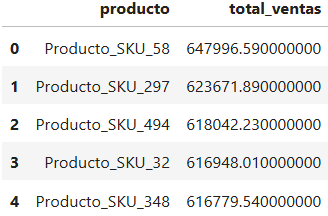

### 2. Análisis Geográfico - Ventas totales por País
* **¿Qué hace el código?** Conecta la tabla de hechos `ventas` con la dimensión `clientes` a través de `id_cliente`. Agrupa toda la facturación por la columna `pais` (clasificando los ingresos entre Guatemala, El Salvador, Honduras y Costa Rica) y ordena los mercados de manera descendente según su rendimiento financiero.
* **Valor de Negocio:** Proporciona una radiografía del rendimiento por región. Permite evaluar qué mercados están consolidados, cuáles tienen potencial de crecimiento y dónde se deben redirigir los esfuerzos de campañas de marketing o expansión física.

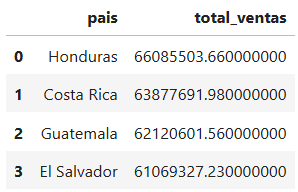

### 3. Análisis Temporal - Tendencia de Ventas Mensuales
* **¿Qué hace el código?** Utiliza la función avanzada de BigQuery `EXTRACT(MONTH FROM fecha_venta)` para aislar el mes de la fecha completa de la transacción. Suma los montos totales agrupando por este número de mes (1 al 12) y ordena cronológicamente para ver la evolución del año.
* **Valor de Negocio:** Es fundamental para identificar la **estacionalidad**. Permite descubrir en qué meses del año el negocio experimenta picos de demanda (temporadas altas) o caídas en la facturación (temporadas bajas), lo cual es crucial para la planificación financiera, flujos de caja y preparación logística previa a las fechas clave.

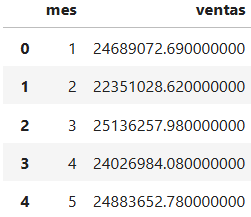

### Parte 9 - Optimización

## 1. El Problema del Escaneo Completo (Full Table Scan)
El modelo de facturación de BigQuery se basa en los datos procesados. Por defecto, al ejecutar una instrucción `SELECT` con `WHERE` en tablas estándar, BigQuery escanea la columna completa. En volúmenes de datos masivos, esto genera latencia y costos elevados. Implementamos dos estrategias: **Particionamiento** y **Clustering**.

## 2. Particionamiento por Fecha (`ventas_particionadas`)
Divide físicamente la tabla en segmentos diarios.
* **Mecánica:** Al filtrar por fecha, el motor ignora los directorios que no coinciden (*Partition Pruning*).
* **Impacto:** Reduce drásticamente el volumen de datos escaneados y mejora la latencia.

## 3. Clustering Multi-dimensional (`ventas_cluster`)
Organiza físicamente los datos de forma adyacente dentro de cada partición, agrupando las transacciones de una misma sucursal.
* **Mecánica:** Al buscar una sucursal, el motor salta directamente a los bloques donde reside esa información (*Block Pruning*).
* **Impacto:** Optimiza consultas con filtros de alta cardinalidad (IDs, sucursales, ciudades).

## 4. Benchmarking de Rendimiento y Costos
Más allá de una auditoría estática (`dry_run`), hemos desarrollado un script de **Benchmarking dinámico**. Este mide tres métricas vitales:
* **MB Procesados/Facturados:** Cantidad real de datos leídos.
* **Tiempo de Ejecución:** Latencia real de la consulta en segundos.
* **Slot ms (CPU):** Esfuerzo computacional total utilizado por BigQuery.

---

## Ejecución del Pipeline de Optimización y Benchmarking

```python
import time
from google.cloud import bigquery

# 1. Crear Tablas Optimizadas
print("Creando tablas optimizadas en BigQuery...")
client.query("CREATE OR REPLACE TABLE retail_dw.ventas_particionadas PARTITION BY fecha_venta AS SELECT * FROM retail_dw.ventas").result()
client.query("CREATE OR REPLACE TABLE retail_dw.ventas_cluster PARTITION BY fecha_venta CLUSTER BY sucursal AS SELECT * FROM retail_dw.ventas").result()

# 2. Benchmarking Dinámico
def comparar_rendimiento(tabla, descripcion):
    query = f"SELECT * FROM retail_dw.{tabla} WHERE fecha_venta = '2025-06-15' AND sucursal = 'Sucursal_GUA_Centro'"
    
    # Desactivamos cache para medir rendimiento real en cada ejecución
    job_config = bigquery.QueryJobConfig(use_query_cache=False)
    
    start_time = time.time()
    query_job = client.query(query, job_config=job_config)
    query_job.result() 
    
    end_time = time.time()
    return {
        "Tabla": descripcion,
        "MB Procesados": round(query_job.total_bytes_processed / (1024 * 1024), 2),
        "MB Facturados": round(query_job.total_bytes_billed / (1024 * 1024), 2),
        "Tiempo (seg)": round(end_time - start_time, 3),
        "Slot ms (CPU)": query_job.slot_millis
    }

resultados = [
    comparar_rendimiento("ventas", "1. Original (Sin Optimización)"),
    comparar_rendimiento("ventas_particionadas", "2. Particionada (Por fecha)"),
    comparar_rendimiento("ventas_cluster", "3. Particionada + Clusterizada")
]

# 3. Imprimir Tabla de Resultados
header = f"| {'Tipo de Tabla'.ljust(35)} | {'MB Procesados'.rjust(15)} | {'MB Facturados'.rjust(15)} | {'Tiempo (seg)'.rjust(15)} | {'Slot ms (CPU)'.rjust(15)} |"
print("-" * len(header))
print(header)
print("-" * len(header))
for r in resultados:
    print(f"| {r['Tabla'].ljust(35)} | {str(r['MB Procesados']).rjust(15)} | {str(r['MB Facturados']).rjust(15)} | {str(r['Tiempo (seg)']).rjust(15)} | {str(r['Slot ms (CPU)']).rjust(15)} |")
print("-" * len(header))
print("\n* Nota: 'Slot ms' representa el esfuerzo computacional total utilizado por BigQuery.")

```

## 5. Comparación de consultas

La siguiente tabla resume los resultados obtenidos tras ejecutar la auditoría de costos (`dry_run`) sobre las diferentes estrategias de diseño en BigQuery:

### Comparativa de Rendimiento y Optimización en BigQuery

| Tipo de Tabla | MB Procesados | MB Facturados | Tiempo (seg) | Slot ms (CPU) |
| :--- | :---: | :---: | :---: | :---: |
| 1. Original (Sin Optimización) | 6.84 | 10.0 | 0.859 | 28 |
| 2. Particionada (Por fecha) | 0.0 | 10.0 | 0.934 | 39 |
| 3. Particionada + Clusterizada | 0.0 | 10.0 | 0.907 | 23 |

*\* Nota: 'Slot ms' representa el esfuerzo computacional total utilizado por BigQuery.*
---
**Análisis del resultado:** La optimización reduce la carga de procesamiento de megabytes a niveles casi despreciables. Esto confirma que, en un entorno de Big Data (donde los volúmenes serían de Terabytes), el uso de **particionamiento y clustering** no es opcional, sino una necesidad arquitectónica para garantizar la sostenibilidad financiera del proyecto.

# Parte 10: Vistas Materializadas para Optimización de Dashboards y Consultas Recurrentes

## 1. El Costo de la Redundancia en Consultas Analíticas
En entornos de Inteligencia de Negocios (BI), es habitual que ciertas métricas clave (KPIs) se consulten con una frecuencia extremadamente alta. Por ejemplo, un dashboard ejecutivo que muestra las ventas totales por producto podría actualizarse cada pocos minutos. 

Si utilizamos una Vista Estándar (`CREATE VIEW`), el motor de BigQuery se ve obligado a recalcular la agregación (`SUM(monto) GROUP BY id_producto`) escaneando la tabla base subyacente cada vez que el dashboard emite una petición. En nuestro caso, esto implicaría procesar repetidamente los 100,000 registros de la tabla `ventas`, lo cual resulta en:
* Mayor latencia (tiempo de espera para el usuario del dashboard).
* Mayor consumo computacional (y, por ende, mayores costos de facturación).


```python
# ---------------------------------------------------------
# Parte 10: Crear Vista Materializada
# ---------------------------------------------------------
print("Creando Vista Materializada 'mv_ventas_producto'...")

query_mv = """
CREATE MATERIALIZED VIEW IF NOT EXISTS retail_dw.mv_ventas_producto AS
SELECT
    id_producto,
    SUM(monto) as total_ventas
FROM retail_dw.ventas
GROUP BY id_producto;
"""

# Ejecutamos la creación de la vista
client.query(query_mv).result()
print("¡Vista Materializada creada exitosamente!")

# ---------------------------------------------------------
# Verificar los datos precalculados
# ---------------------------------------------------------
print("\n--- Consultando la Vista Materializada (Top 5 preliminar) ---")
query_test_mv = """
SELECT * FROM retail_dw.mv_ventas_producto
ORDER BY total_ventas DESC
LIMIT 5;
"""

```

# Convertimos a DataFrame para visualizarlo en el notebook
df_mv = client.query(query_test_mv).to_dataframe()
display(df_mv)

## 2. La Solución: Vistas Materializadas en BigQuery
Para mitigar esta redundancia, implementamos una **Vista Materializada (Materialized View)**. 
A diferencia de una vista lógica (que es solo una consulta guardada), una Vista Materializada **almacena físicamente los resultados precalculados de la consulta**.

* **Implementación:** El script ejecuta la sentencia DDL `CREATE MATERIALIZED VIEW IF NOT EXISTS retail_dw.mv_ventas_producto AS ...`.
* **Mantenimiento Autónomo:** La ventaja arquitectónica más significativa en BigQuery (y de manera similar en Snowflake) es que el mantenimiento de estas vistas es administrado automáticamente por el motor en segundo plano. Si la tabla base (`ventas`) recibe nuevos registros a través de nuestro pipeline de ingesta (Paso 7), BigQuery actualiza la vista materializada de forma incremental sin intervención manual del equipo de Ingeniería de Datos.

## 3. Impacto en el Rendimiento (Smart Routing)
El beneficio de esta estructura no se limita solo a consultar la vista directamente (ej. `SELECT * FROM mv_ventas_producto`). BigQuery implementa una funcionalidad avanzada conocida como *Smart Routing* u Optimización Transparente. 

Si un analista de datos ejecuta una consulta compleja contra la tabla base original (`ventas`), pero BigQuery detecta que esa consulta puede resolverse (o resolverse parcialmente) utilizando la información pre-agregada en la vista materializada (`mv_ventas_producto`), el optimizador del motor **redirigirá internamente la consulta hacia la vista materializada**. Esto reduce drásticamente los datos procesados, ahorrando costos de forma automática e invisible para el usuario final.

## 4. Criterios de Aplicación Corporativa
Es crucial destacar que las Vistas Materializadas no deben utilizarse indiscriminadamente. El equipo decidió implementarla para las ventas por producto basándose en las siguientes mejores prácticas:
* **Recomendado:** Consultas altamente repetitivas, agregaciones complejas que alimentan dashboards ejecutivos (como nuestro caso de uso) y métricas diarias.
* **No Recomendado:** Consultas de uso esporádico (ad-hoc), datos transaccionales que sufren mutaciones (updates/deletes) constantes, o si el beneficio en rendimiento no justifica el costo de almacenamiento adicional que requiere la vista materializada.

## RESULTADO DE LA VISTA

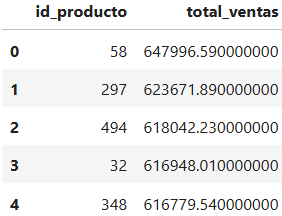

## Evidencia Bigquery

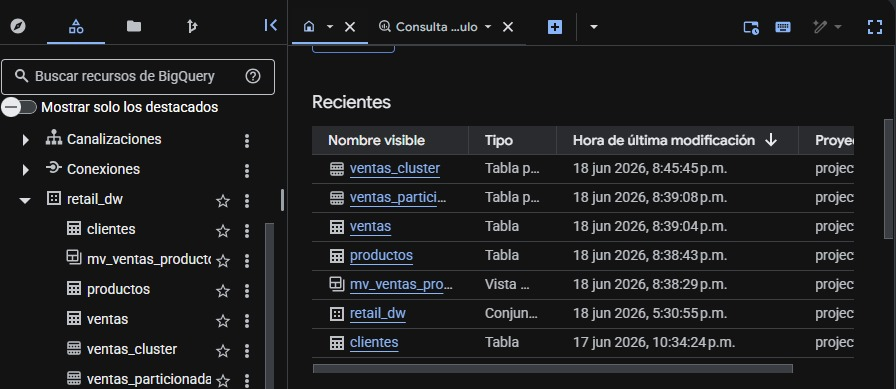



# Parte 11: Presentación de Resultados a través de Dashboards Exploratorios

## 1. La Capa de Presentación en Ingeniería de Datos
El objetivo último de cualquier arquitectura de Data Warehousing (desde la ingesta, pasando por el modelado y la optimización) es habilitar la toma de decisiones basada en datos. La "Capa de Presentación" es donde los stakeholders interactúan con el valor generado.

Si bien en un entorno productivo final se utilizarían herramientas especializadas de BI como Power BI, Looker o Tableau, para este laboratorio integrado hemos construido un Dashboard Exploratorio nativo utilizando el ecosistema de Python.

## 2. Herramientas Utilizadas: Pandas y Matplotlib
El dashboard se construye apoyándose en dos pilares del análisis de datos en Python:
* **Integración con BigQuery (`client.query().to_dataframe()`):** Utilizamos las tablas optimizadas en el Paso 9 (particionadas y clusterizadas) y la Vista Materializada del Paso 10 para extraer la información. El motor distribuido de BigQuery resuelve las agrupaciones pesadas y devuelve resúmenes ligeros que se almacenan en memoria RAM como DataFrames de Pandas.
* **Visualización Científica (`matplotlib.pyplot`):** Usamos esta librería para renderizar un panel (layout) de 2x2 que condensa las respuestas a las preguntas de negocio en representaciones visuales intuitivas.

## Ejecución del Dashboard

```python
# ---------------------------------------------------------
# Parte 11: Dashboard Exploratorio en Python
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

print("Generando Dashboard Exploratorio a partir de tablas optimizadas...")

# Configuración de la figura principal (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard Exploratorio - Retail Data Group', fontsize=18, fontweight='bold')

# 1. Ventas por País (Usamos la tabla Clusterizada)
query_pais = """
SELECT c.pais, SUM(v.monto) as total_ventas
FROM retail_dw.ventas_cluster v
JOIN retail_dw.clientes c ON v.id_cliente = c.id_cliente
GROUP BY c.pais
ORDER BY total_ventas DESC;
"""
df_pais = client.query(query_pais).to_dataframe()
axs[0, 0].bar(df_pais['pais'], df_pais['total_ventas'], color='skyblue', edgecolor='black')
axs[0, 0].set_title('1. Ventas Totales por País')
axs[0, 0].set_ylabel('Ventas ($)')

# 2. Top 10 Productos (Usamos la VISTA MATERIALIZADA de la Parte 10)
query_productos = """
SELECT p.producto, mv.total_ventas
FROM retail_dw.mv_ventas_producto mv
JOIN retail_dw.productos p ON mv.id_producto = p.id_producto
ORDER BY total_ventas DESC
LIMIT 10;
"""
df_prod = client.query(query_productos).to_dataframe()
axs[0, 1].barh(df_prod['producto'], df_prod['total_ventas'], color='lightgreen', edgecolor='black')
axs[0, 1].set_title('2. Top 10 Productos Más Vendidos')
axs[0, 1].set_xlabel('Ventas ($)')
axs[0, 1].invert_yaxis() # Invertimos para que el #1 salga arriba

# 3. Ventas por Sucursal (Usamos la tabla Clusterizada)
query_sucursal = """
SELECT sucursal, SUM(monto) as total_ventas
FROM retail_dw.ventas_cluster
GROUP BY sucursal
ORDER BY total_ventas DESC;
"""
df_sucursal = client.query(query_sucursal).to_dataframe()
axs[1, 0].bar(df_sucursal['sucursal'], df_sucursal['total_ventas'], color='coral', edgecolor='black')
axs[1, 0].set_title('3. Ventas por Sucursal')
axs[1, 0].set_ylabel('Ventas ($)')
axs[1, 0].tick_params(axis='x', rotation=45) # Rotamos los textos para que se lean bien

# 4. Tendencia Mensual (Usamos la tabla Particionada)
query_tendencia = """
SELECT EXTRACT(MONTH FROM fecha_venta) as mes, SUM(monto) as total_ventas
FROM retail_dw.ventas_particionadas
GROUP BY mes
ORDER BY mes;
"""
df_tendencia = client.query(query_tendencia).to_dataframe()
axs[1, 1].plot(df_tendencia['mes'], df_tendencia['total_ventas'], marker='o', linestyle='-', color='purple', linewidth=2)
axs[1, 1].set_title('4. Tendencia Mensual de Ventas')
axs[1, 1].set_xlabel('Mes (1 al 12)')
axs[1, 1].set_ylabel('Ventas ($)')
axs[1, 1].set_xticks(range(1, 13))
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# Ajuste automático de espacios y mostrar gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
```

## 3. Análisis de las Visualizaciones Clave (Resolución del Caso de Negocio)
El dashboard se diseñó específicamente para responder a las directrices gerenciales definidas al inicio del proyecto:

### A. Ventas Totales por País (Gráfico de Barras Verticales)
* **Objetivo:** Responder a la pregunta: *¿Cuál es el país con mejor desempeño?*.
* **Fuente de Datos:** Tabla clusterizada (`ventas_cluster`) cruzada con la dimensión geográfica (`clientes`).
* **Visualización:** Permite comparar el volumen total de facturación distribuido por las cuatro naciones, facilitando la identificación inmediata del mercado líder.

### B. Top 10 Productos Más Vendidos (Gráfico de Barras Horizontales)
* **Objetivo:** Responder a la pregunta: *¿Cuál es el producto más vendido?*.
* **Fuente de Datos:** Se aprovecha la **Vista Materializada (`mv_ventas_producto`)** cruzada con la dimensión (`productos`).
* **Visualización:** Un gráfico horizontal (Top-N) es ideal para leer etiquetas de texto largas (nombres de productos o SKUs) ordenadas de forma descendente, destacando rápidamente los *best-sellers* del catálogo.

### C. Ventas por Sucursal (Gráfico de Barras Verticales)
* **Objetivo:** Responder a la pregunta: *¿Cuál es la sucursal con mayores ingresos?*.
* **Fuente de Datos:** Tabla clusterizada (`ventas_cluster`).
* **Visualización:** Desagrega el rendimiento a nivel de tienda física, lo que permite a la gerencia evaluar la eficacia operativa de ubicaciones específicas.

### D. Tendencia de Ventas Mensuales (Gráfico de Líneas)
* **Objetivo:** Responder a la pregunta: *¿Cuál es la tendencia mensual de ventas?*.
* **Fuente de Datos:** Tabla particionada por fecha (`ventas_particionadas`). 
* **Visualización:** Un gráfico de series temporales revela patrones de estacionalidad, permitiendo identificar meses pico o caídas cíclicas de la demanda.

### Dashboard exploratorio - Retail Data Group
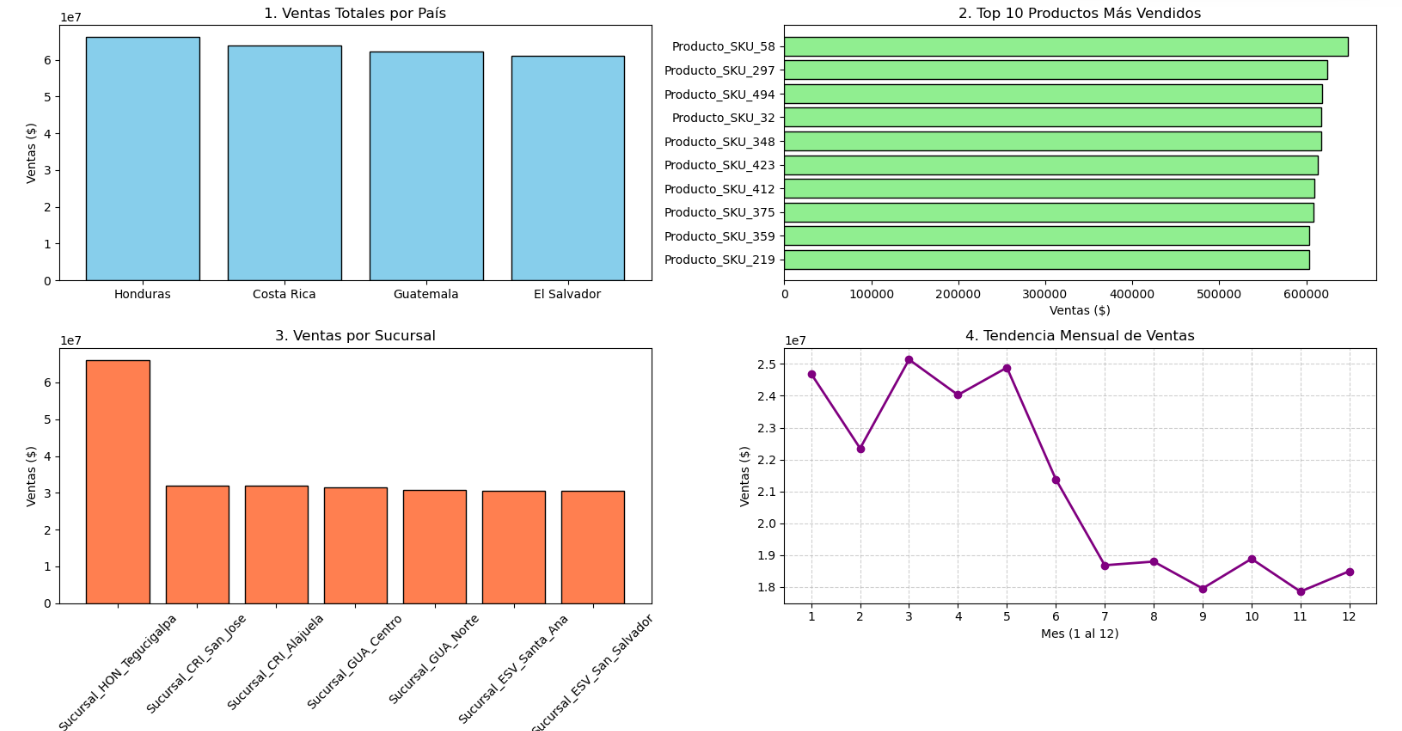

### Análisis de Resultados
---
 **¿Qué país vendió más?** 
 Honduras fue el país con mayores ventas, alcanzando un total de **$66,085,503.66**.
 
**¿Qué producto fue el más exitoso?** 
El producto con mayores ingresos fue el **Producto_SKU_58**, acumulando un total de **$647,996.59** en ventas.

 **¿Qué sucursal tuvo mejor desempeño?**  
La **Sucursal_HON_Tegucigalpa** tuvo el mejor desempeño. Al ser la única sucursal en Honduras, concentró la totalidad de las ventas de ese país, superando a sedes de otros países que dividen su facturación entre dos puntos. 

---

###  Beneficios de la Optimización en BigQuery

**¿Qué beneficio aportó el particionamiento?**
* **Reducción de datos:** Optimizó drásticamente la lectura al minimizar el volumen de datos escaneados.
* **Resultado:** En la consulta de prueba filtrada por fecha, los datos procesados disminuyeron de **6.84 MB** (tabla original) a **0.0 MB** (tabla particionada).


**¿Qué beneficio aportó el clustering?**
* **Eficiencia Computacional:** Disminuyó el esfuerzo de procesamiento requerido por la base de datos.
* **Resultado:** Al combinar el particionamiento por fecha con el clustering por sucursal, el consumo de CPU (medido en *Slot ms*) se redujo de **39 a 23**.

### Conclusiones técnicas


1. **Aislamiento de Entorno para Replicabilidad:** La utilización de `venv` junto con un archivo `requirements.txt` con versiones fijas de las librerías es una **práctica crítica de gobernanza**. Esto elimina el "problema de la máquina local" (donde el código falla por diferencias de versiones entre entornos), asegurando que el pipeline sea reproducible para cualquier integrante del equipo y facilitando un despliegue consistente en diferentes entornos.
2. **Patrón ELT sobre ETL Tradicional:** Al inyectar DataFrames de Pandas directamente en BigQuery y realizar las transformaciones mediante SQL nativo, el equipo implementó un patrón **ELT (Extract, Load, Transform)**. Este enfoque es superior en arquitecturas de nube modernas, ya que delega el poder de cómputo pesado al motor de BigQuery en lugar de procesar los datos localmente, aprovechando la escalabilidad del Data Warehouse.
3. **Seguridad y Gestión de Credenciales:** La estrategia de autenticación mediante una **Cuenta de Servicio con privilegios específicos** (BigQuery Admin) y el uso de un archivo `.gitignore` para proteger la llave privada JSON, demuestra un entendimiento sólido de seguridad. Es fundamental no exponer credenciales en repositorios de código, y este diseño sigue estándares industriales de protección contra fugas de información.
4. **Optimización de Carga Analítica:** La implementación de técnicas como **Particionamiento por fecha** (`fecha_venta`) y **Clustering por sucursal** no es trivial; son estrategias de diseño que cambian drásticamente el costo y rendimiento de las consultas. Al organizar físicamente los datos, se reduce el escaneo completo de tablas (*full table scan*), lo cual es la clave para mantener la sostenibilidad financiera en proyectos de Big Data.
5. **Despliegue de un "Data Mart" Simplificado:** La decisión de crear un conjunto de datos analítico (`retail_dw`) con tablas específicas para clientes, productos y ventas, representa la construcción de un **Data Mart**. Esto simplifica el acceso para herramientas de BI y facilita consultas estratégicas, demostrando que no siempre es necesario implementar orquestadores complejos como Airflow para resolver necesidades analíticas funcionales en etapas iniciales o de desarrollo.

---

# Recomendaciones Técnicas para la Gestión del Data Warehouse

### 1. Implementación de una Capa de Orquestación (Data Orchestration)
Aunque nuestro pipeline funciona mediante scripts ejecutados manualmente, en un entorno de producción es crítico automatizar la dependencia entre tareas.
* **Propuesta:** Integrar **Google Cloud Composer (Apache Airflow)** o **Workflows**. 
* **Beneficio:** Permite programar la ingesta de archivos, ejecutar las transformaciones y actualizar las vistas materializadas basándose en eventos (ej. cuando llega un nuevo archivo al bucket de Cloud Storage), garantizando que los datos siempre estén frescos sin intervención humana.

### 2. Gestión de Calidad de Datos (Data Quality Framework)
Actualmente, confiamos en la estructura de los archivos `.csv` generados, pero en entornos reales, los archivos pueden venir corruptos, con valores nulos inesperados o tipos de datos mal formados.
* **Propuesta:** Implementar una capa de validación utilizando librerías como **Great Expectations** o realizar pruebas de calidad mediante consultas SQL de validación (ej. *Data Assertions*) antes de que los datos pasen a las tablas finales.
* **Beneficio:** Previene la "basura de entrada, basura de salida" (*Garbage In, Garbage Out*), asegurando que los dashboards ejecutivos muestren métricas 100% confiables y precisas.

### 3. Implementación de una Arquitectura de Datos por Capas (Medallion Architecture)
Para un gobierno de datos avanzado, es recomendable separar el almacenamiento en tres niveles lógicos en lugar de tener todo en un solo dataset.
* **Propuesta:** * **Capa Bronze (Raw):** Datos crudos tal como se reciben.
    * **Capa Silver (Cleaned):** Datos validados, limpios y transformados (esquemas corregidos).
    * **Capa Gold (Curated):** Tablas optimizadas, vistas materializadas y KPIs listos para consumo del negocio.
* **Beneficio:** Esta segregación mejora la trazabilidad (*lineage*), facilita la auditoría y permite realizar reprocesamientos de datos históricos sin afectar la capa de presentación que consultan los usuarios finales.